# Causal Entropic Forces

Here's how the algorithm works:
1. From the current state, sample `NUM_ROLLOUTS`
2. Estimate the probability of sampling trajectory i `p(traj_i)` using kernel density estimation
3. Define the volume of trajectory i as `vol_i = 1 / p(traj_i)`
4. Calculate the normalized volume of a trajectory `norm_vol_i = vol_i / \sum_i vol_i`
5. Calculate the causal entropic force `2 * T_C / T_R \mean_i f_i * \log norm_vol_i`, where `f_i` is the initial force of trajectory i and the value `T_C / T_R` governs how much more you want to exploit (acting following the entropic force) vs explore (sampling a trajectory)
6. Use the causal entropic force to update the current state

In [1]:
import numpy as np
import scipy

from matplotlib import pyplot as plt
from matplotlib import patches as patches
from matplotlib import cm

import copy

In [2]:
np.random.seed(0)

dtype = np.float32

## Hyperparameters

In [3]:
T_R     = 4e5   # temperature of random agent (K)
T_C     = 2e6   # temperature of causal agent (K)
TAU     = 10.   # simulation time horizon (seconds)
EPSILON = .025  # timesteps (seconds)

In [4]:
NUM_SUBSAMPLES = 3

In [5]:
NUM_ROLLOUTS = 50_000

## Particle-in-a-box environment and dynamics

In [ ]:
M     = 1e-21 # mass (kg)
L     = 400                               # length (meters) 
Q_MIN = np.array([0., 0.  ], dtype=dtype) # minimum box displacements
Q_MAX = np.array([L , L/5.], dtype=dtype) # maximum box displacements

In [7]:
def new_p(p, f):
    p     = f * EPSILON
    p_max = M * np.abs(Q_MAX - Q_MIN) / EPSILON
    return np.sign(p) * np.minimum(p_max, np.abs(p))

In [8]:
def new_q(q, p):
    return q  +  EPSILON * p / M

In [9]:
def enforce_elastic_collisions(p, q):
    q  = np.maximum(q, 2 * Q_MIN - q)
    p *= np.sign(q - Q_MIN)
    q  = np.minimum(q, 2 * Q_MAX - q)
    p *= np.sign(Q_MAX - q)
    return p, q

In [10]:
def new_phase_space(p, q, f):
    p    = new_p(p, f)
    q    = new_q(q, p)
    p, q = enforce_elastic_collisions(p, q)
    return p, q

## Random rollouts

In [6]:
timesteps = int(TAU / EPSILON)

In [11]:
def generate_fs(num_samples):
    # scale calculation formula from https://math.stackexchange.com/a/1426406
    return np.random.normal( loc   = 0. ,
                             scale = np.sqrt(M * scipy.constants.Boltzmann * T_R) / EPSILON ,
                             size  = (num_samples, 2) ).astype(dtype)

In [12]:
def rollouts(p, q, num_samples):
    """
    paths.shape = (timesteps, num_samples, q_dim)
    """
    ps = np.tile(p[None, :], (num_samples, 1))
    qs = np.tile(q[None, :], (num_samples, 1))

    paths = copy.deepcopy(qs[None, :])

    fs       = generate_fs(num_samples)
    first_fs = copy.deepcopy(fs)
    
    for i in range(timesteps):
        ps, qs = new_phase_space(ps, qs, fs)
        paths  = np.append(paths, qs[None, :], axis=0)
        fs     = generate_fs(num_samples)

    return paths, first_fs

## Causal Entropic Forcing

In [13]:
def log_vol_fracs(paths):
    vol       = 1. / scipy.stats.gaussian_kde(paths).pdf(paths)
    vol_fracs = vol / vol.sum() 
    return np.log(vol_fracs)

In [14]:
def subsample(paths):
    # idea and code from Google Gemini to speed up KDE
    sub_indices = np.linspace( 0 ,
                               timesteps - 1 ,
                               NUM_SUBSAMPLES ,
                               dtype=np.int32 ) 
    sub_paths = paths[sub_indices, :, :]
    return sub_paths.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS)

In [15]:
def entropic_force(p, q):
    paths, fs = rollouts(p, q, NUM_ROLLOUTS)
    sub_paths = subsample(paths[1:]) # remove first state bc conditional
    return np.mean( fs * log_vol_fracs(sub_paths)[:, None] , axis=0 )

## Rollouts

In [16]:
p = np.array([0.   , 0.   ])
q = np.array([L/10., L/10.])

path = copy.deepcopy(q[None, :])

for timestep in range(100):
    print(timestep, q)
    f_c  = 2 * T_C / T_R * entropic_force(p, q)
    p, q = new_phase_space(p, q, f_c)
    path = np.append(path, q[None, :], axis=0)

0 [40. 40.]
1 [40.53854324 38.98063433]
2 [40.63174919 38.14109986]
3 [42.74087873 39.46971615]
4 [42.2120383  39.05657861]
5 [42.0749558  40.29409079]
6 [40.87258483 40.25702743]
7 [39.82521577 40.3922173 ]
8 [41.62625358 41.46699154]
9 [41.66222239 40.96857333]
10 [42.15771712 40.25155556]
11 [42.64673208 40.69738883]
12 [42.94242484 41.83499598]
13 [43.74577589 40.48147532]
14 [42.93671519 40.69812054]
15 [43.29059407 43.90268295]
16 [41.87503704 44.37111152]
17 [41.50343445 44.73426603]
18 [41.8313388  45.44414292]
19 [41.38712943 45.79934333]
20 [42.74510086 44.87525314]
21 [43.83538321 43.87029439]
22 [45.29638232 44.42943518]
23 [46.19765862 46.38287908]
24 [46.88931234 46.1710318 ]
25 [48.35955454 44.04930575]
26 [47.97545723 44.09194502]
27 [47.23850536 44.56015364]
28 [48.80075632 43.45598301]
29 [49.05059979 42.19691313]
30 [48.88712027 40.2810376 ]
31 [48.31486101 41.06879038]
32 [48.86645505 42.03304907]
33 [49.82950567 42.11020655]
34 [50.84933699 44.21376884]
35 [51.8405

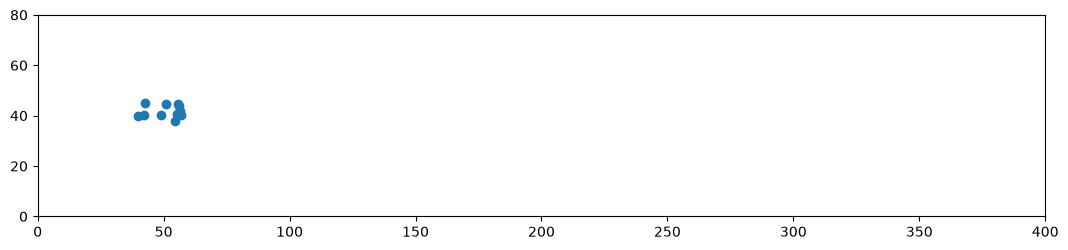

In [17]:
fig, ax = plt.subplots(figsize=(13, 13))
# from https://stackoverflow.com/a/37437395
# ax.add_patch(patches.Rectangle(Q_MIN, L, L/5., edgecolor='k', fill=False))
# ax.plot(*path.T)
ax.scatter(*path[::10].T)
ax.set_xlim(Q_MIN[0], Q_MAX[0])
ax.set_ylim(Q_MIN[1], Q_MAX[1])
ax.set(aspect='equal')
plt.show()